In [1]:
#Lab1
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt

print("Downloading MNIST dataset...")

# 1. 下载并归一化数据
X, y = fetch_openml('mnist_784', data_home='./', return_X_y=True, as_frame=False)
X = X.astype(np.float32) / 255.0

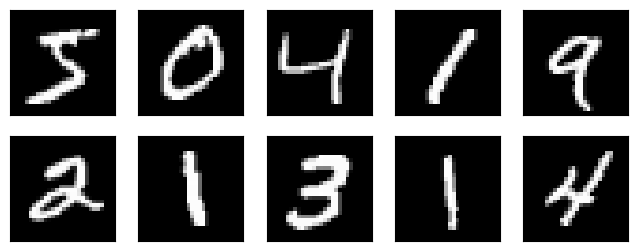

In [2]:
# 2. 创建画布
plt.figure(figsize=(8, 3))

# 3. 用循环绘制前10张图片
for i in range(10):
    plt.subplot(2, 5, i + 1)                     # 2行5列布局
    plt.imshow(X[i].reshape(28, 28), cmap='gray') # 显示第i张图
    plt.xticks([]), plt.yticks([])               # 去掉坐标轴刻度

# 4. 显示
plt.show()

In [3]:
# 取前 1000 张图片
X_small = X[:1000]
y_small = y[:1000]

np.savez('1k.npz', X_small, y_small) #用 numpy 把两个变量 X_small 和 y_small 保存到一个压缩文件 1k.npz 里。
np.load('1k.npz') #把刚才保存的 1k.npz 文件重新加载回来。

NpzFile '1k.npz' with keys: arr_0, arr_1

In [4]:
# 统计每个类别的数量
unique, counts = np.unique(y_small, return_counts=True) # 在数组 y_small（前 1000 张图片的标签）里，找出不重复的类别值以及每个类别出现的次数。
print("Number of images per class:")
for u, c in zip(unique, counts): # 用 zip 把 unique 和 counts 按位置配对，逐类打印结果。
    print(f"Digit {u}: {c} images")

Number of images per class:
Digit 0: 97 images
Digit 1: 116 images
Digit 2: 99 images
Digit 3: 93 images
Digit 4: 105 images
Digit 5: 92 images
Digit 6: 94 images
Digit 7: 117 images
Digit 8: 87 images
Digit 9: 100 images


In [5]:
# 选择要可视化的数字，这里直接固定为 '2'
index = np.nonzero(y_small == '2')[0]
print(f"\nNumber of digit 2 images: {len(index)}")


Number of digit 2 images: 99


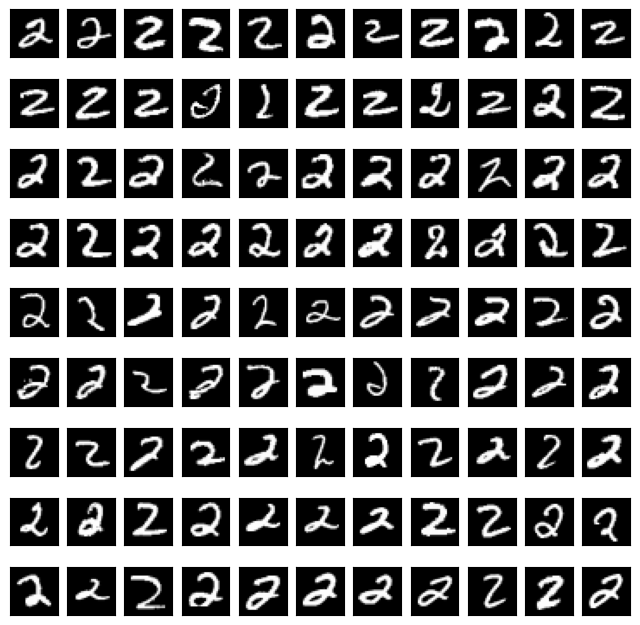

In [6]:
# 可视化前99张数字2的图片
plt.figure(figsize=(8, 8))
for i in range(99):
    plt.subplot(9, 11, i + 1)
    plt.imshow(X_small[index[i]].reshape(28, 28), cmap='gray')
    plt.xticks([]), plt.yticks([]) 
plt.show()

In [7]:
# ------------------------------
# Lab 2: KNN on MNIST subset
# ------------------------------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 1. 加载上次保存的数据
data = np.load('1k.npz', allow_pickle=True)
X, y = data['arr_0'], data['arr_1']

In [8]:
# 2. 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



KNN Accuracy (k=3): 0.8650


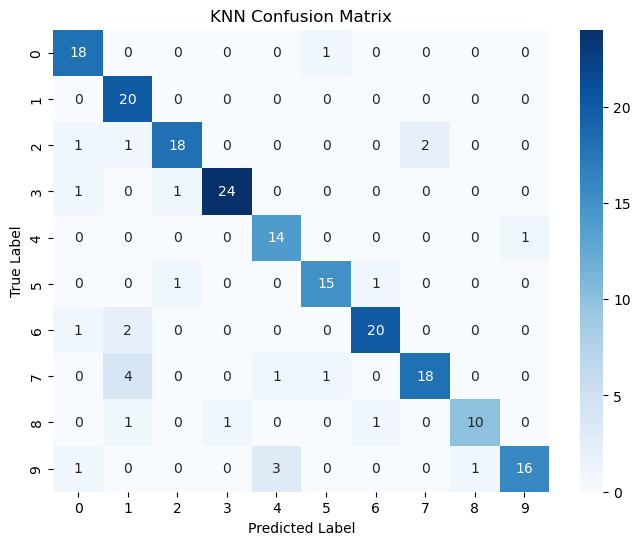

In [9]:
# 3. 创建并训练 KNN 模型（k=3 可调整）
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 4. 对测试集进行预测
y_pred = knn.predict(X_test)

# 5. 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"\nKNN Accuracy (k=3): {accuracy:.4f}")

# 6. 绘制混淆矩阵（可视化分类效果）
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN Confusion Matrix")
plt.show()

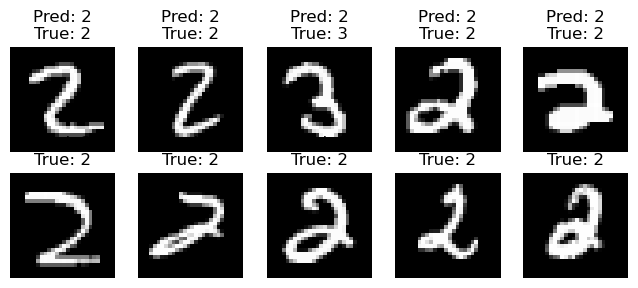


Accuracy for different K values:
k=1, accuracy=0.8500
k=3, accuracy=0.8650
k=5, accuracy=0.8750
k=7, accuracy=0.8750
k=9, accuracy=0.8600


In [10]:
# 7. 可视化：展示预测为 '2' 的图片
indices = np.where(y_pred == '2')[0]

plt.figure(figsize=(8, 3))
for i, idx in enumerate(indices[:10]):  # 只看前10张
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}\nTrue: {y_test[idx]}")
    plt.axis('off')
plt.show()

# 8. 比较不同k值的准确率
print("\nAccuracy for different K values:")
for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    print(f"k={k}, accuracy={acc:.4f}")